# Context
This is an improved version of the legacy MLP notebook, where the training loops are now all isolated. The experiment is nearly identical, in the sense that the legacy notebook (see legacy_notebooks/) used a dataset which included only columns where the price is in the 99th percentile, since we found major outliers (that we could not explain at that point in time).

Note that we also trained an ordinary linear regression model only on the `distance_km` feature, that cona be found under `legacy_notebooks/City-Center-Linear-Regression.ipynb`, but it is relatively uninteresting.

We compare this MLP v1 to a linear baseline (sklearn DummyRegressor) and a mean baseline. The `legacy_notebooks/MLP.ipynb` had no baseline model comparison. 
Translating the old linear regression only on the city center seemed not valuable.

In [28]:
from team_project.data.loading import (
    load_data_single_run,
    load_data_multi_run,
    load_mean_baseline,
    load_linear_baseline,
    load_data_single_run_cross_validation,
    load_data_multi_run_cross_validation,
    load_cross_validation_mean_baseline,
    load_cross_validation_linear_baseline,
    load_final_metrics,
    load_final_mean_baseline,
    load_final_linear_baseline,
)
from team_project.visualization.plotting import plot_hyperparameter_runs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [29]:

# Global aesthetic settings
plt.rcParams["figure.dpi"] = 120  # Crisp resolution

sns.set_theme(
    style="ticks",
    font="sans-serif",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.bottom": True,
        "ytick.left": True,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

# MLP City Center (v1)

In [30]:
history = load_data_single_run("mlp-city-center-v1")["history"]
mean_baseline_metrics = load_mean_baseline("mlp-city-center-v1", "val")
linear_baseline_metrics = load_linear_baseline("mlp-city-center-v1", "val")

In [31]:
print(history)

{'train_loss': [293750.8128984953, 291494.2625765111, 284501.44702204474, 270431.9234889059, 252240.12903874967, 236601.6378972998, 228814.80062932367, 226811.85380602843, 226349.49450873502, 226038.7492209417, 225803.817481191, 225532.6364841359, 225285.21722924238, 225064.1056331293, 224842.26748398048, 224555.95300644764, 224326.9125263007, 224097.7604101911, 223859.08164172087, 223717.52703292368], 'val_loss': [288725.5501058378, 284673.3370237299, 274198.7242647059, 257015.37151153074, 238825.8368357286, 227209.07116198752, 223232.19817429813, 222482.83835366534, 222150.30896278966, 221881.94306344696, 221609.84339488635, 221342.78882575757, 221105.3595421123, 220856.80093443627, 220629.43313419117, 220366.08647365196, 220125.57391237744, 219899.66587288326, 219664.64137004234, 219454.25609959892]}


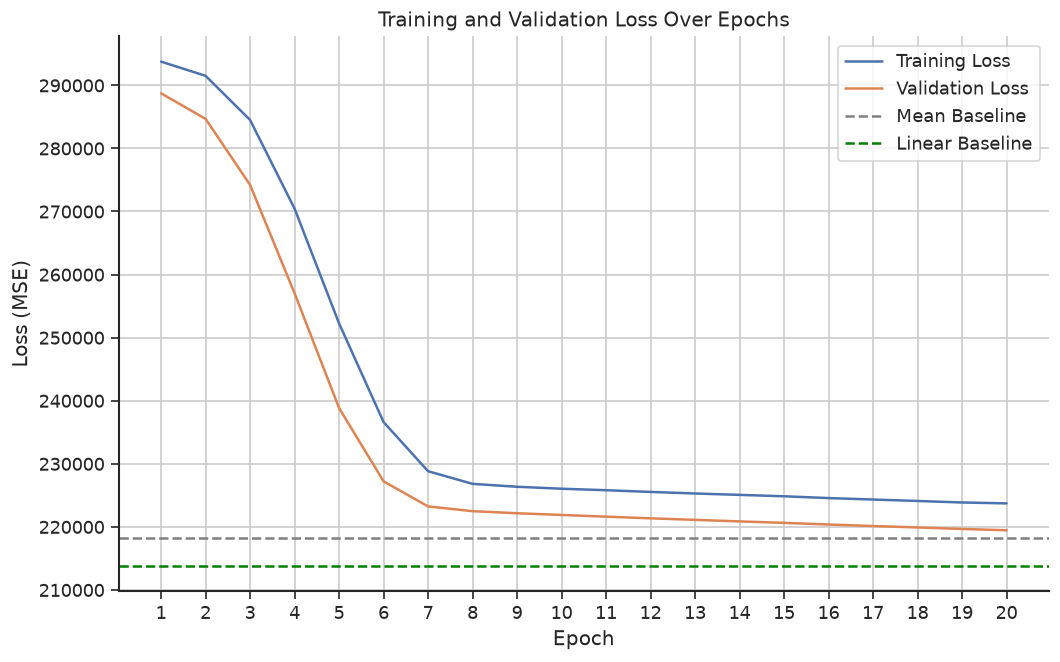

In [32]:
epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss"], label='Training Loss')
plt.plot(epochs, history["val_loss"], label='Validation Loss')
plt.axhline(
    y=mean_baseline_metrics["mse"],
    color="gray",
    linestyle="--",
    label="Mean Baseline"
)
plt.axhline(
    y=linear_baseline_metrics["mse"],
    color="green",
    linestyle="--",
    label="Linear Baseline"
)
plt.xticks(epochs)
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

MLP config single/mlp-v1.toml, using a learning rate of 0.001 and a batch size of 64.

The optimizer will be adam and the loss_fn mse.

We can see that the loss is very high, for both training and validation, we are likely underfitting because our feature set is way too small.

We cannot even outperform the mean baseline, while the linear basline actually had a slight outperformance, meaning our features have some predictive power, but the MLP may struggle with the current featureset.

# Hyperparameter tuning

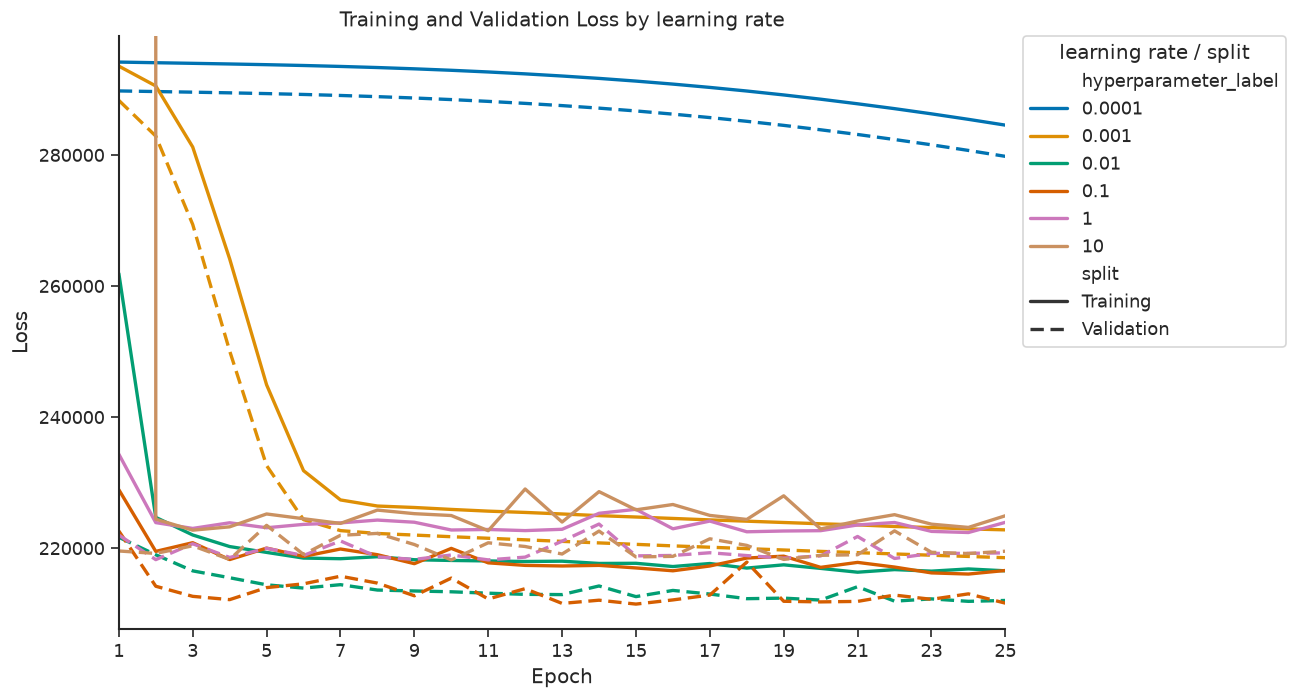

In [33]:
multi_lr_data = load_data_multi_run('mlp-city-center-v1-learning-rates')
plot_hyperparameter_runs(multi_lr_data, "lr", "learning rate")


We can observe that 0.01 is learning more and not getting stuck in local minima like our 0.001 of the initial configuration.

# Optimizing the batch size
Since we know that 0.01 is a reasonable learning rate, we will now test the model with that learning rate, but against different batch sizes instead.

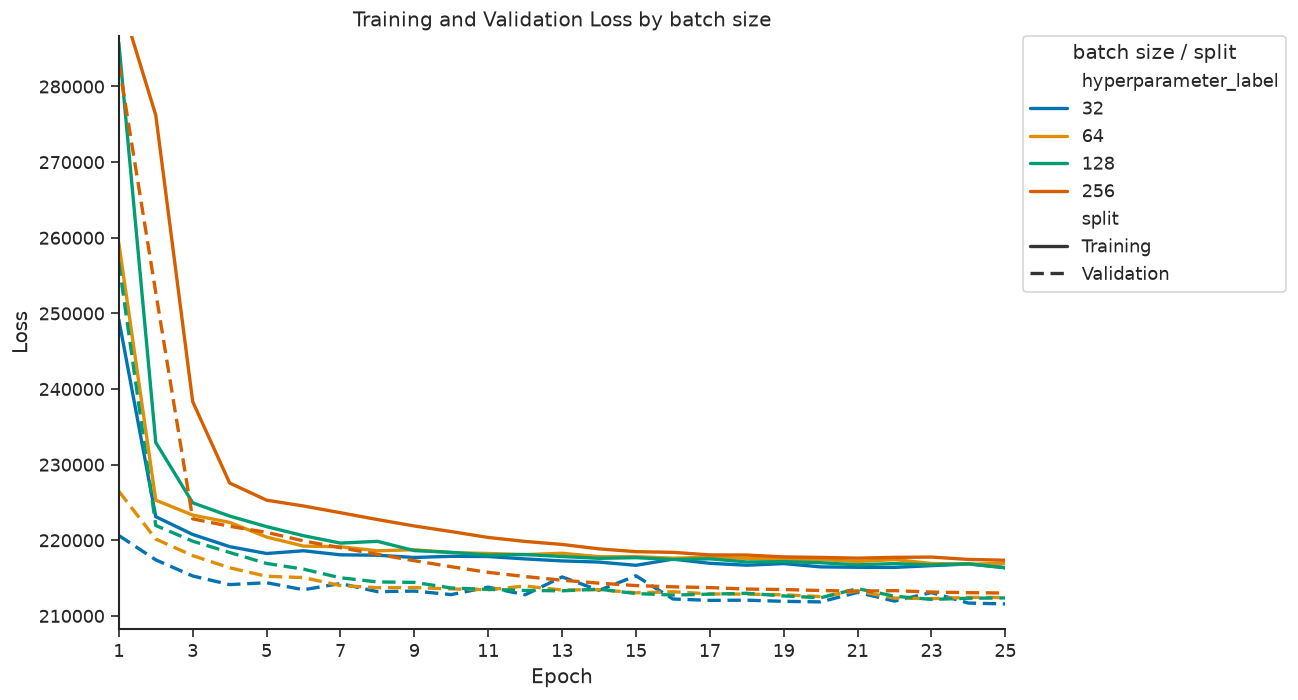

In [34]:
multi_batch_size_data = load_data_multi_run('mlp-city-center-v1-batch-sizes')
plot_hyperparameter_runs(multi_batch_size_data, "batch_size", "batch size")

Choosing a batch size of 64 seems reasonable here, we don't have to change anything.

# Cross Validation

The plots below repeat the same checks as above, but use the k-fold cross-validation artifacts instead of the single validation split.

In [35]:
cv_history = load_data_single_run_cross_validation("mlp-city-center-v1")["history"]
cv_mean_baseline_metrics = load_cross_validation_mean_baseline("mlp-city-center-v1")
cv_linear_baseline_metrics = load_cross_validation_linear_baseline("mlp-city-center-v1")

cv_summary = pd.DataFrame([
    {
        "model": "MLP",
        "mse": cv_history["val_loss"][-1],
        "mse_std": cv_history["val_loss_std"][-1],
    },
    {
        "model": "Mean baseline",
        "mse": cv_mean_baseline_metrics["mse"],
        "mse_std": cv_mean_baseline_metrics["mse_std"],
    },
    {
        "model": "Linear baseline",
        "mse": cv_linear_baseline_metrics["mse"],
        "mse_std": cv_linear_baseline_metrics["mse_std"],
    },
])

cv_summary

,model,mse,mse_std
0,MLP,223545.955238,128844.471853
1,Mean baseline,221727.319049,128859.919081
2,Linear baseline,218010.477782,128385.458413


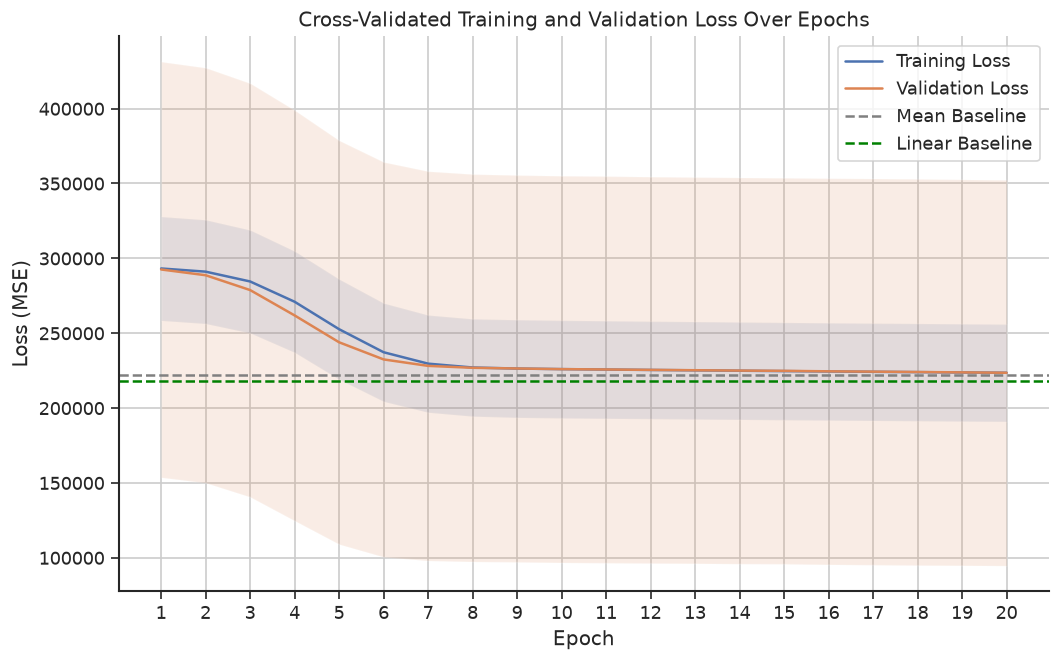

In [36]:
epochs = range(1, len(cv_history["train_loss"]) + 1)

train_loss = pd.Series(cv_history["train_loss"])
val_loss = pd.Series(cv_history["val_loss"])
train_loss_std = pd.Series(cv_history["train_loss_std"])
val_loss_std = pd.Series(cv_history["val_loss_std"])

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label="Training Loss")
plt.fill_between(
    epochs,
    train_loss - train_loss_std,
    train_loss + train_loss_std,
    alpha=0.15,
)
plt.plot(epochs, val_loss, label="Validation Loss")
plt.fill_between(
    epochs,
    val_loss - val_loss_std,
    val_loss + val_loss_std,
    alpha=0.15,
)
plt.axhline(
    y=cv_mean_baseline_metrics["mse"],
    color="gray",
    linestyle="--",
    label="Mean Baseline"
)
plt.axhline(
    y=cv_linear_baseline_metrics["mse"],
    color="green",
    linestyle="--",
    label="Linear Baseline"
)
plt.xticks(epochs)
plt.title("Cross-Validated Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

The cross-validation run shows the same high-level pattern as the single validation split: the model does not clearly beat the simple baselines, and the validation loss remains high.
But this time the linear model does not seem to clearly beat the mlp, which means that the single validation set from before wasnt showing the full picture.

## Cross-Validated Learning Rate Tuning

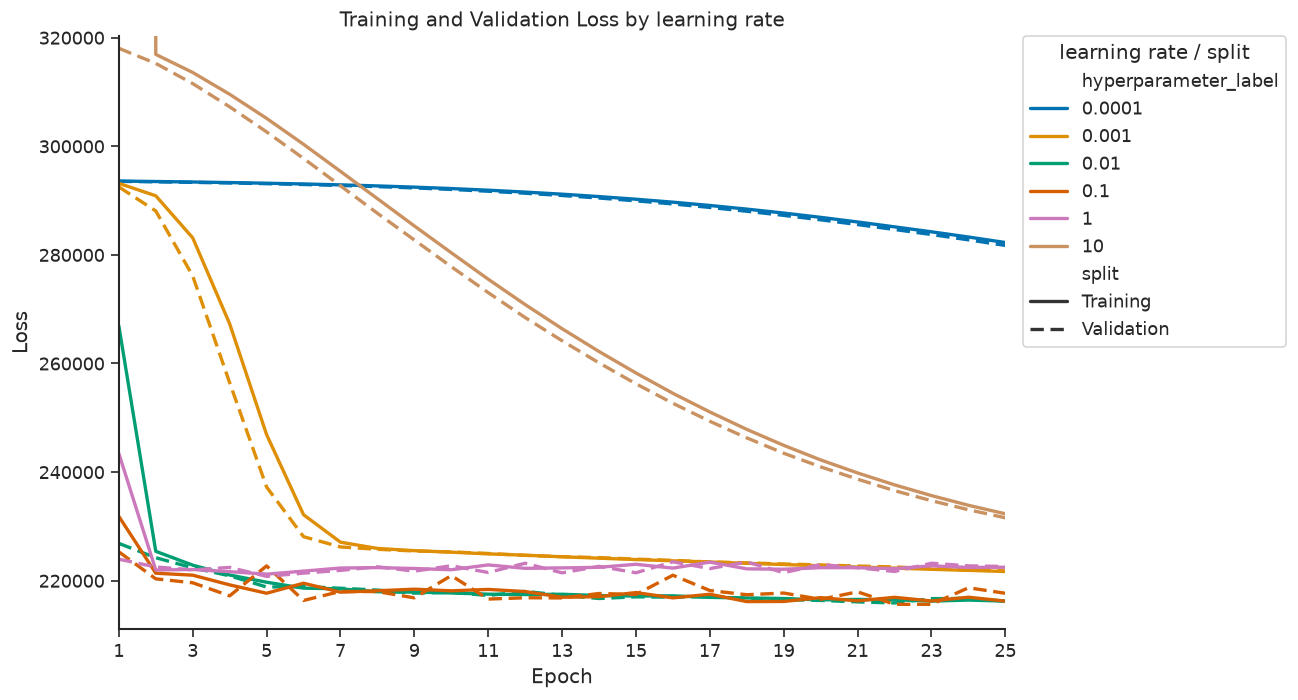

In [37]:
cv_multi_lr_data = load_data_multi_run_cross_validation("mlp-city-center-v1-learning-rates")
plot_hyperparameter_runs(cv_multi_lr_data, "lr", "learning rate")

Using cross-validation makes the comparison less dependent on a single split, but the learning-rate sweep still does not solve the underfitting problem.

## Cross-Validated Batch Size Tuning

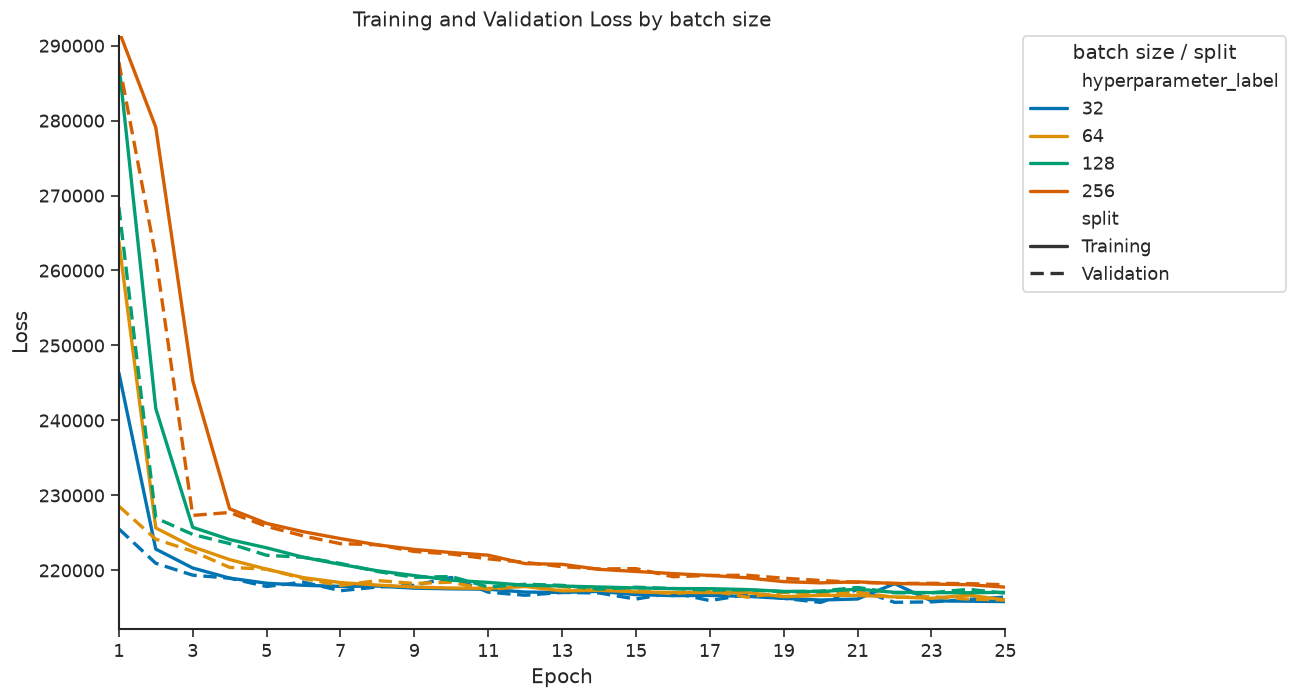

In [38]:
cv_multi_batch_size_data = load_data_multi_run_cross_validation("mlp-city-center-v1-batch-sizes")
plot_hyperparameter_runs(cv_multi_batch_size_data, "batch_size", "batch size")

The batch-size sweep also confirms the earlier result: tuning the batch size alone does not materially improve the model.

# Test Performance

After choosing the model setup, we train once on the full training split and compare final performance on the held-out test set.

In [39]:
test_mlp_metrics = load_final_metrics("mlp-city-center-v1")
test_mean_baseline_metrics = load_final_mean_baseline("mlp-city-center-v1")
test_linear_baseline_metrics = load_final_linear_baseline("mlp-city-center-v1")

test_performance = pd.DataFrame([
    {"model": "MLP", **test_mlp_metrics},
    {"model": "Mean baseline", **test_mean_baseline_metrics},
    {"model": "Linear baseline", **test_linear_baseline_metrics},
])

test_performance = test_performance[["model", "mse", "rmse", "mae", "r2"]]
test_performance.round({
    "mse": 2,
    "rmse": 2,
    "mae": 2,
    "r2": 4,
})

,model,mse,rmse,mae,r2
0,MLP,55968.37,236.58,156.04,-0.0354
1,Mean baseline,54604.57,233.68,156.13,-0.0102
2,Linear baseline,50961.98,225.75,148.42,0.0572


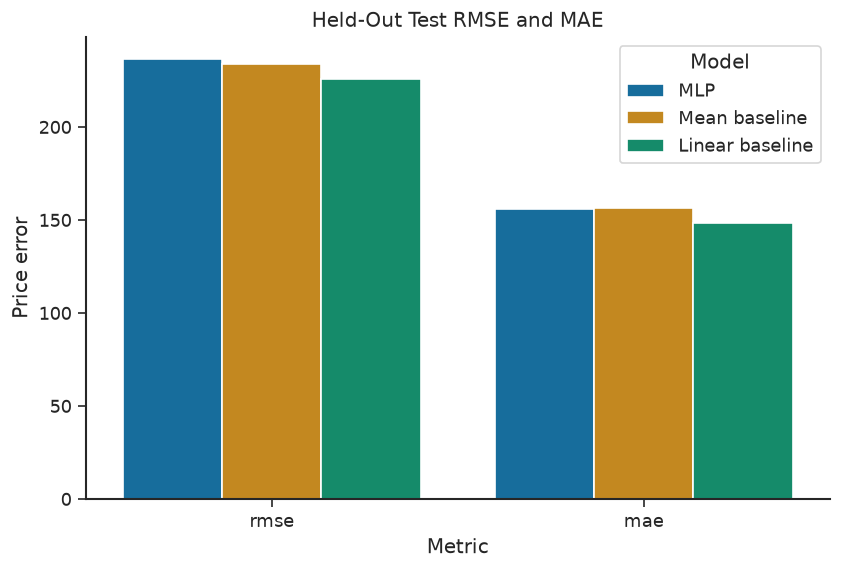

In [40]:
test_error_metrics = test_performance.melt(
    id_vars="model",
    value_vars=["rmse", "mae"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=test_error_metrics,
    x="metric",
    y="value",
    hue="model",
    palette="colorblind",
)
plt.title("Held-Out Test RMSE and MAE")
plt.xlabel("Metric")
plt.ylabel("Price error")
plt.legend(title="Model")
sns.despine()
plt.show()

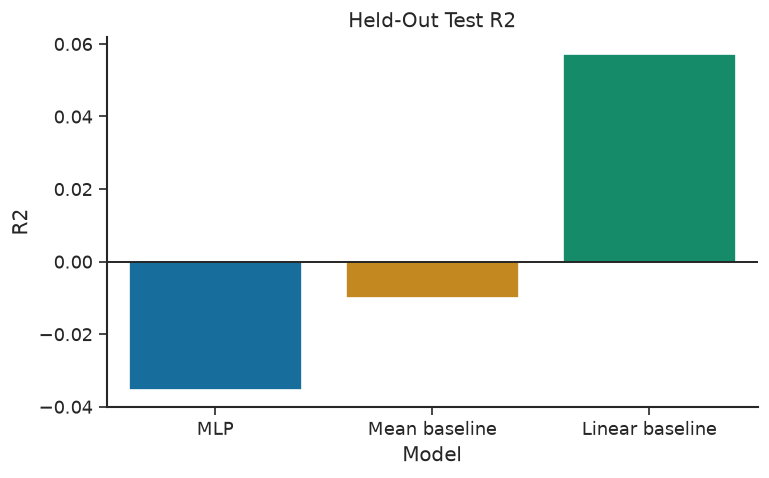

In [41]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=test_performance,
    x="model",
    y="r2",
    hue="model",
    palette="colorblind",
    legend=False,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Held-Out Test R2")
plt.xlabel("Model")
plt.ylabel("R2")
sns.despine()
plt.show()

The held-out test set confirms the main pattern from cross-validation: the MLP is close to the mean baseline, while the linear baseline is slightly better on MSE, RMSE, MAE, and R2. The simple feature set remains the limiting factor.